In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
store_sales = pd.read_csv('/content/drive/MyDrive/Datasets/train.csv')
store_sales


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [6]:
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [7]:
store_sales['date'] = pd.to_datetime(store_sales['date'])
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


After converting the date datatype from objetc to date time now we would want to group by the month

In [8]:
store_sales['date'] = store_sales['date'].dt.to_period("M")

In [9]:
store_sales.drop(['item', 'store'], axis = 1, inplace = True)

In [10]:
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype    
---  ------  --------------   -----    
 0   date    913000 non-null  period[M]
 1   sales   913000 non-null  int64    
dtypes: int64(1), period[M](1)
memory usage: 13.9 MB


In [11]:
monthly_sales = store_sales.groupby('date').sum().reset_index()
monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype    
---  ------  --------------  -----    
 0   date    60 non-null     period[M]
 1   sales   60 non-null     int64    
dtypes: int64(1), period[M](1)
memory usage: 1.1 KB


since the date column is period[M] We're converting it to timestamp for easy data visualization

In [12]:
monthly_sales['date'] = monthly_sales['date'].dt.to_timestamp()
monthly_sales.head(10)

,date,sales
0,2013-01-01,454904
1,2013-02-01,459417
2,2013-03-01,617382
3,2013-04-01,682274
4,2013-05-01,763242
5,2013-06-01,795597
6,2013-07-01,855922
7,2013-08-01,766761
8,2013-09-01,689907
9,2013-10-01,656587


Data visualization

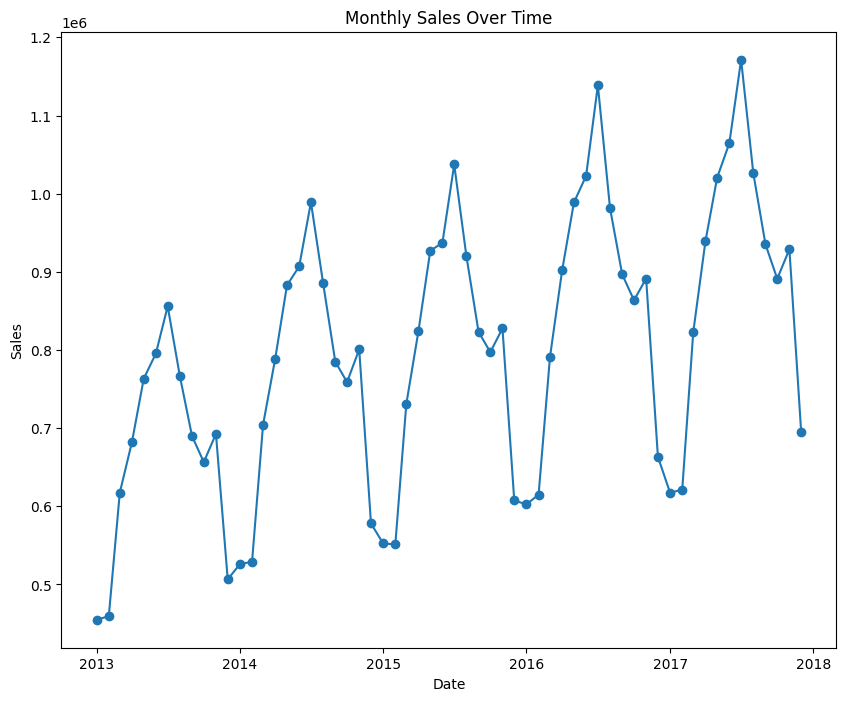

In [13]:
plt.figure(figsize=(10, 8))
plt.plot(monthly_sales['date'], monthly_sales['sales'], marker = 'o', linestyle='-')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


In [14]:
monthly_sales['sales_diff'] = monthly_sales['sales'].diff()
monthly_sales = monthly_sales.dropna()
monthly_sales.head(13)


,date,sales,sales_diff
1,2013-02-01,459417,4513.0
2,2013-03-01,617382,157965.0
3,2013-04-01,682274,64892.0
4,2013-05-01,763242,80968.0
5,2013-06-01,795597,32355.0
6,2013-07-01,855922,60325.0
7,2013-08-01,766761,-89161.0
8,2013-09-01,689907,-76854.0
9,2013-10-01,656587,-33320.0
10,2013-11-01,692643,36056.0


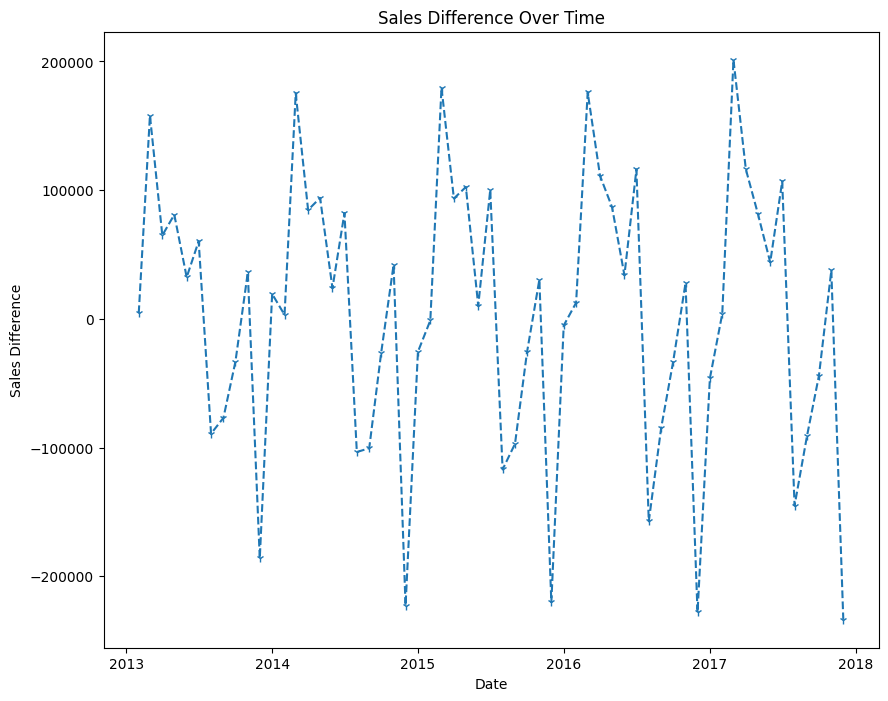

In [15]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10, 8))
plt.plot(monthly_sales['date'], monthly_sales['sales_diff'], linestyle = '--', marker = "1")
plt.xlabel('Date')
plt.ylabel('Sales Difference')
plt.title('Sales Difference Over Time')
plt.show()

Removing Sales and Date columns

In [16]:
supervised_data = monthly_sales.drop(['sales', 'date'], axis = 1)
supervised_data.head()

,sales_diff
1,4513.0
2,157965.0
3,64892.0
4,80968.0
5,32355.0


In [17]:
for i in range(1,13):
  col_name = 'month_' + str(i)
  supervised_data[col_name] = supervised_data['sales_diff'].shift(i)
supervised_data = supervised_data.dropna().reset_index(drop=True)
supervised_data.tail()


,sales_diff,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
42,-144990.0,106769.0,43938.0,81824.0,116195.0,201298.0,4063.0,-46105.0,-228037.0,27811.0,-33194.0,-84663.0,-157224.0
43,-91140.0,-144990.0,106769.0,43938.0,81824.0,116195.0,201298.0,4063.0,-46105.0,-228037.0,27811.0,-33194.0,-84663.0
44,-44103.0,-91140.0,-144990.0,106769.0,43938.0,81824.0,116195.0,201298.0,4063.0,-46105.0,-228037.0,27811.0,-33194.0
45,37677.0,-44103.0,-91140.0,-144990.0,106769.0,43938.0,81824.0,116195.0,201298.0,4063.0,-46105.0,-228037.0,27811.0
46,-233667.0,37677.0,-44103.0,-91140.0,-144990.0,106769.0,43938.0,81824.0,116195.0,201298.0,4063.0,-46105.0,-228037.0


In [18]:
supervised_data['sales_diff'].describe()

,sales_diff
count,47.000000
mean,3599.638298
std,111953.893868
min,-233667.000000
25%,-65384.000000
50%,12518.000000
75%,90148.000000
max,201298.000000


# Splitting data into two types:
- Training Data
- Test Data

In [19]:
Train_data = supervised_data[:-12]
Test_data = supervised_data[-12:]
print(f"Train_data shape: {Train_data.shape}")
print("Test_data shape:" + str(Test_data.shape))

Train_data shape: (35, 13)
Test_data shape:(12, 13)


Now we want to use minmaxscaler to minimize the range of the data

In [20]:
scaler = MinMaxScaler(feature_range=(-1 , 1))
scaler.fit(Train_data)
Train_data = scaler.transform(Train_data)
Test_data = scaler.transform(Test_data)

In [21]:
X_train, Y_train = Train_data[:,1:], Train_data[:,0:1]
X_test, Y_test = Test_data[:, 1:], Test_data[:, 0:1]
Y_train = Y_train.ravel()
Y_test = Y_test.ravel()
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (35, 12)
Y_train shape: (35,)
X_test shape: (12, 12)
Y_test shape: (12,)


Make a new data frame for predictions

In [55]:
sales_dates = monthly_sales['date'][-12:].reset_index(drop=True)
predict_df = pd.DataFrame(sales_dates)
predict_df

,date
0,2017-01-01
1,2017-02-01
2,2017-03-01
3,2017-04-01
4,2017-05-01
5,2017-06-01
6,2017-07-01
7,2017-08-01
8,2017-09-01
9,2017-10-01


In [23]:
act_sales = monthly_sales['sales'][-13:].to_list()
act_sales

[663411,
 617306,
 621369,
 822667,
 938862,
 1020686,
 1064624,
 1171393,
 1026403,
 935263,
 891160,
 928837,
 695170]

In [40]:
monthly_sales.tail(13)

,date,sales,sales_diff
47,2016-12-01,663411,-228037.0
48,2017-01-01,617306,-46105.0
49,2017-02-01,621369,4063.0
50,2017-03-01,822667,201298.0
51,2017-04-01,938862,116195.0
52,2017-05-01,1020686,81824.0
53,2017-06-01,1064624,43938.0
54,2017-07-01,1171393,106769.0
55,2017-08-01,1026403,-144990.0
56,2017-09-01,935263,-91140.0


# Make a linear regression model

In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
lr_pre = lr_model.predict(X_test)
lr_pre

array([ 0.0427074 ,  0.17284957,  1.09083796,  0.71220971,  0.58376708,
        0.33753568,  0.79053303, -0.71169155, -0.29772672, -0.01470231,
        0.24425358, -1.02944627])

In [32]:
lr_pre = lr_pre.reshape(-1, 1)
lr_pre

array([[ 0.0427074 ],
       [ 0.17284957],
       [ 1.09083796],
       [ 0.71220971],
       [ 0.58376708],
       [ 0.33753568],
       [ 0.79053303],
       [-0.71169155],
       [-0.29772672],
       [-0.01470231],
       [ 0.24425358],
       [-1.02944627]])

In [37]:
# This is a matrix - we concatenate the prediction and test
lr_pre_test_set = np.concatenate([lr_pre, X_test], axis=1)
lr_pre_test_set = scaler.inverse_transform(lr_pre_test_set)

In [34]:
len(lr_pre_test_set)

12

In [49]:
# Prediction for the last 12 months 2027-01 till 2027-12
lr_pre_test_set
# First col (-15496.21) is the y prediction value from the X test values we feeded it

array([[ -15496.21493431, -228037.        ,   27811.        ,
         -33194.        ,  -84663.        , -157224.        ,
         116054.        ,   33934.        ,   86780.        ,
         111069.        ,  175924.        ,   12518.        ,
          -5133.        ],
       [  11031.37815765,  -46105.        , -228037.        ,
          27811.        ,  -33194.        ,  -84663.        ,
        -157224.        ,  116054.        ,   33934.        ,
          86780.        ,  111069.        ,  175924.        ,
          12518.        ],
       [ 198150.00014217,    4063.        ,  -46105.        ,
        -228037.        ,   27811.        ,  -33194.        ,
         -84663.        , -157224.        ,  116054.        ,
          33934.        ,   86780.        ,  111069.        ,
         175924.        ],
       [ 120972.12302654,  201298.        ,    4063.        ,
         -46105.        , -228037.        ,   27811.        ,
         -33194.        ,  -84663.        , -157224

In [56]:
result_list = []
for i in range(0, len(lr_pre_test_set)):
  result_list.append(lr_pre_test_set[i][0] + act_sales[i])
lr_pre_series = pd.Series(result_list, name="Linear Prediction")
predict_df = predict_df.merge(lr_pre_series, left_index = True, right_index = True)
predict_df

,date,Linear Prediction
0,2017-01-01,6.479148e+05
1,2017-02-01,6.283374e+05
2,2017-03-01,8.195190e+05
3,2017-04-01,9.436391e+05
4,2017-05-01,1.033653e+06
5,2017-06-01,1.065286e+06
6,2017-07-01,1.201561e+06
7,2017-08-01,1.002123e+06
8,2017-09-01,9.415142e+05
9,2017-10-01,9.080646e+05


In [82]:
# Find the RMSE to see value how far off our prediction is to the actual data
lr_rmse = np.sqrt(mean_squared_error(predict_df['Linear Prediction'], act_sales[1:13]))
lr_mae = mean_absolute_error(predict_df['Linear Prediction'], act_sales[1:13])
lr_r2 = r2_score(predict_df['Linear Prediction'], act_sales[1:13])

print(f"Linear Regression RMSE: {lr_rmse}")
print(f"Linear Regression MAE: {lr_mae}")
print(f"Linear Regression R2: {lr_r2}")



Linear Regression RMSE: 16221.272385416869
Linear Regression MAE: 12433.184266490736
Linear Regression R2: 0.9906152516380969


In [68]:
monthly_sales['sales'][-12:]

,sales
48,617306
49,621369
50,822667
51,938862
52,1020686
53,1064624
54,1171393
55,1026403
56,935263
57,891160


# Data Visualisation:
Actual Sales vs Predicted Sales

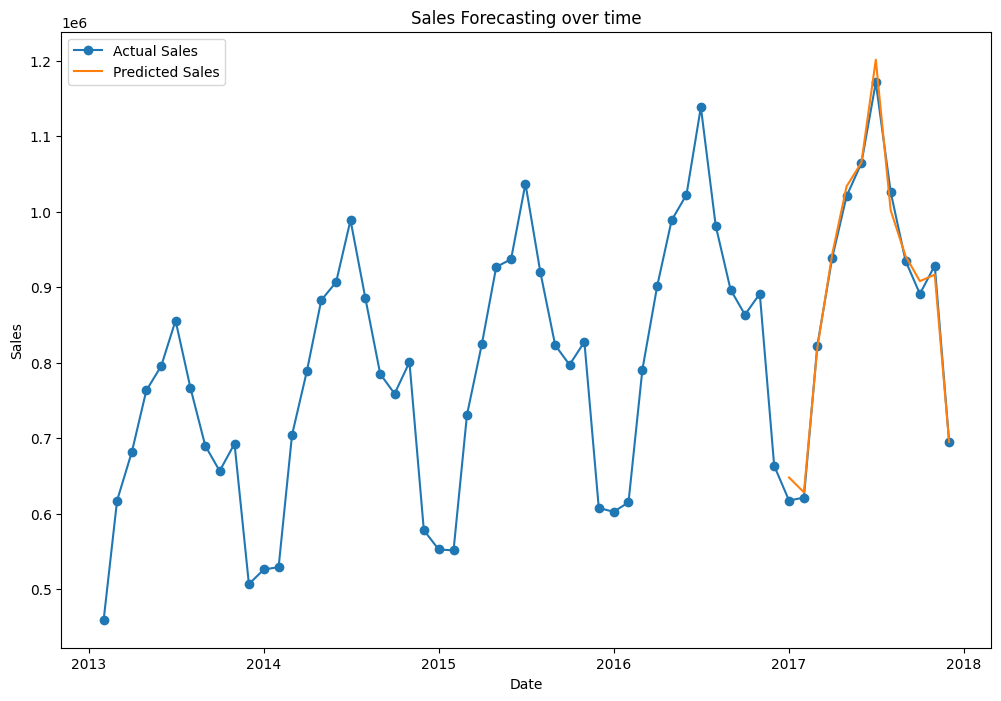

In [88]:
plt.figure(figsize=(12, 8))
# Plot graph for actual sales
plt.plot(monthly_sales['date'], monthly_sales['sales'], marker = 'o', linestyle = '-')
# Plot prediction graph for Jan 2017 to December 2017
plt.plot(predict_df['date'], predict_df['Linear Prediction'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting over time")
plt.legend(['Actual Sales', 'Predicted Sales'])
plt.show()

In [92]:
monthly_sales.tail(13)

,date,sales,sales_diff
47,2016-12-01,663411,-228037.0
48,2017-01-01,617306,-46105.0
49,2017-02-01,621369,4063.0
50,2017-03-01,822667,201298.0
51,2017-04-01,938862,116195.0
52,2017-05-01,1020686,81824.0
53,2017-06-01,1064624,43938.0
54,2017-07-01,1171393,106769.0
55,2017-08-01,1026403,-144990.0
56,2017-09-01,935263,-91140.0


In [104]:
jan2017_diff = monthly_sales.loc[monthly_sales['date'] == '2017-01-01', 'sales_diff'].values[0]
jan2017_diff

np.float64(-46105.0)

In [106]:
# grab the last 12 sales_diff values (Jan 2017 -> Dec 2017)
last_12_diffs = monthly_sales['sales_diff'].iloc[-12:].values

# reshape into the format predict expects: one row, 12 features
jan2018_diff_pred = lr_model.predict([last_12_diffs])
print(jan2018_diff_pred)

[-247433.59004854]


Jan 2018 Prediction Value

In [110]:
jan2018_prediction = monthly_sales.loc[monthly_sales['date'] == '2017-12-01', 'sales'].values[0] + jan2018_diff_pred[0]  # Dec 2017 actual + predicted diff


np.float64(447736.4099514629)